### Data Cleaning

In [ ]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [15]:
df['country'] = df['country'].fillna('Unknown')

In [16]:
df.dropna(subset=['date_added'],inplace=True)

In [17]:
df.dropna(subset=['duration'],inplace=True)

In [18]:
df['date_added'] = pd.to_datetime(df['date_added'],format='mixed')

In [19]:
df.dropna(subset=['rating'],inplace=True)

In [21]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

### Checks unique values

In [24]:
df['rating'].unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str

In [25]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
count,8790,8790,8790,6169,7965,8790,8790,8790.000000,8790,8790,8790,8790,8790.000000,8790
unique,8790,2,8790,4526,7678,749,NaN,NaN,14,220,513,8758,NaN,12
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN,July
freq,1,6126,1,19,19,2809,NaN,NaN,3205,1791,362,4,NaN,827
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 21:44:01.638225,2014.183163,NaN,NaN,NaN,NaN,2018.873606,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,2008.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,NaN,2018.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-03 00:00:00,2017.000000,NaN,NaN,NaN,NaN,2019.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-19 18:00:00,2019.000000,NaN,NaN,NaN,NaN,2020.000000,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN,2021.000000,NaN


In [26]:
df['listed_in'] = df['listed_in'].str.split(',').str[0].str.strip()

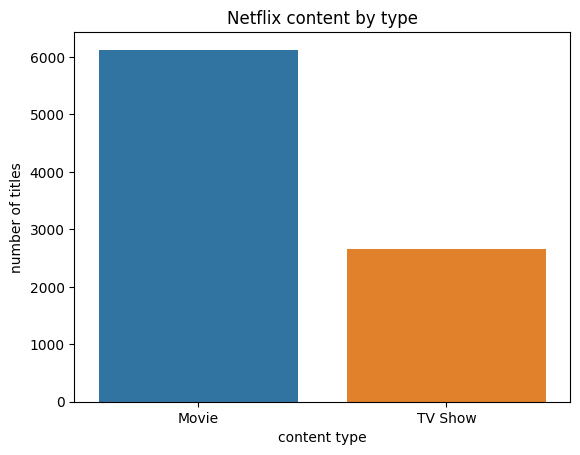

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df,x='type',hue='type')
plt.title('Netflix content by type')
plt.xlabel('content type')
plt.ylabel('number of titles')
plt.show()

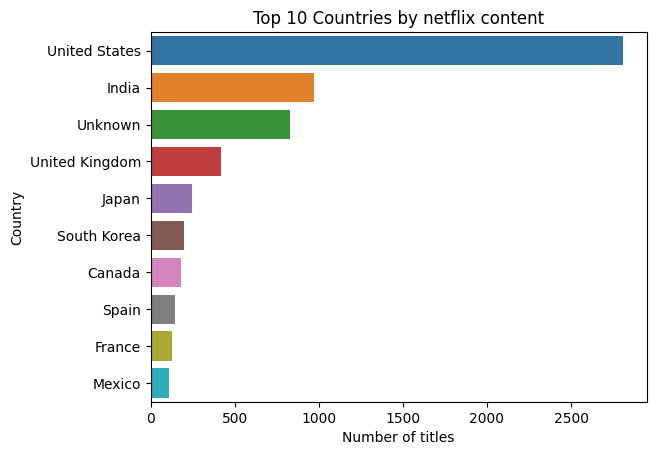

In [35]:
top_countries = df['country'].value_counts().head(10)
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    legend=False
)
plt.title('Top 10 Countries by netflix content')
plt.xlabel('Number of titles')
plt.ylabel('Country')
plt.show()

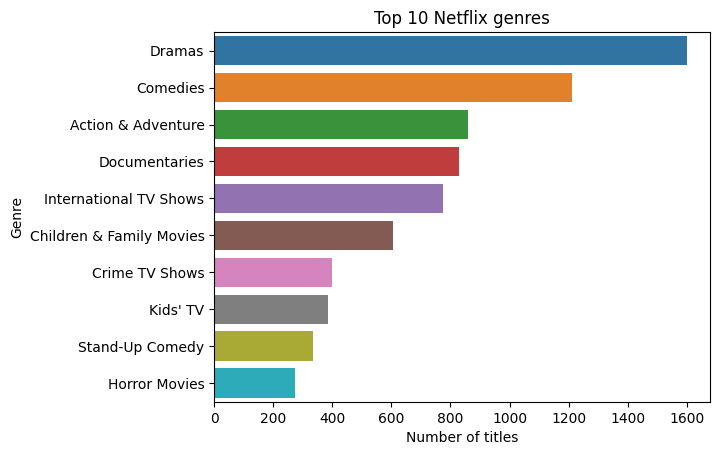

In [37]:
top_genres = df['listed_in'].value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    legend=False
)
plt.title('Top 10 Netflix genres')
plt.xlabel('Number of titles')
plt.ylabel('Genre')

plt.show()

Text(0, 0.5, 'Number of titles')

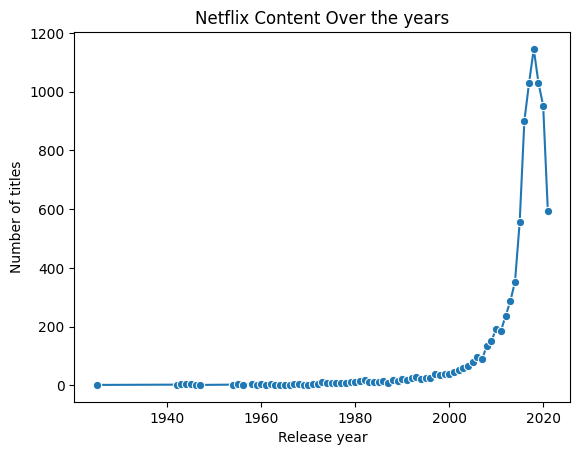

In [39]:
year_counts = df['release_year'].value_counts().sort_index()

sns.lineplot(x=year_counts.index,y=year_counts.values, marker='o')
plt.title('Netflix Content Over the years')
plt.xlabel('Release year')
plt.ylabel('Number of titles')

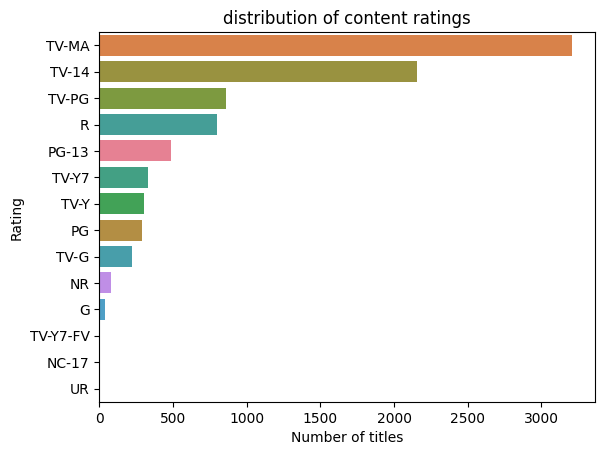

In [40]:
sns.countplot(data=df,y='rating',order = df['rating'].value_counts().index,hue='rating',legend=False)
plt.title('distribution of content ratings')
plt.xlabel('Number of titles')
plt.ylabel('Rating')
plt.show()

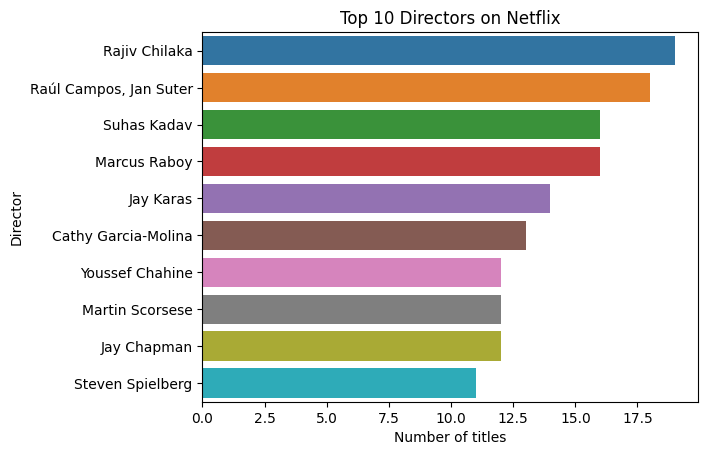

In [41]:
top_directors = df['director'].dropna().value_counts().head(10)

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    legend=False
)
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Number of titles')
plt.ylabel('Director')
plt.show()

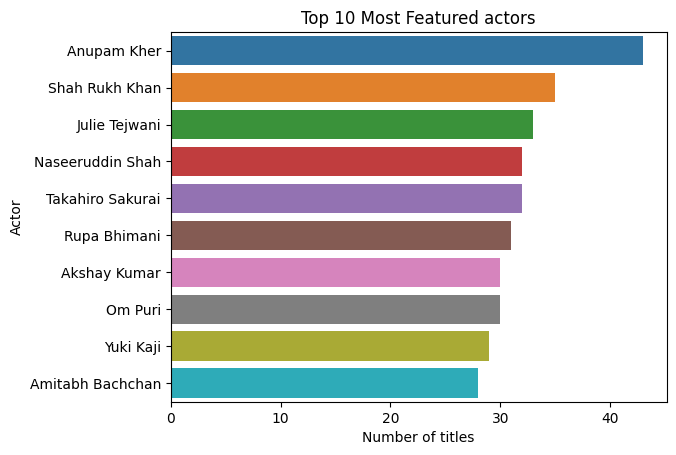

In [42]:
top_cast = (df['cast'].dropna().str.split(',').explode().str.strip().value_counts().head(10))
sns.barplot(x=top_cast.values,y=top_cast.index, hue=top_cast.index,legend=False)
plt.title('Top 10 Most Featured actors')
plt.xlabel('Number of titles')
plt.ylabel('Actor')
plt.show()

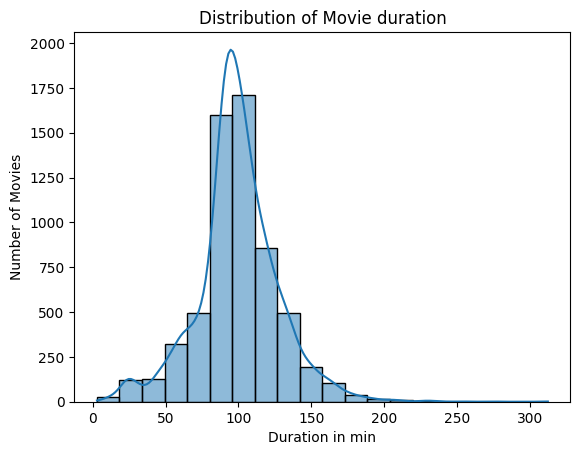

In [44]:
movies =df[df['type'] == 'Movie'].copy()
movies['duration'] = movies['duration'].str.replace('min','').astype(int)
sns.histplot(movies['duration'],bins=20,kde=True)
plt.title('Distribution of Movie duration')
plt.xlabel('Duration in min')
plt.ylabel('Number of Movies')
plt.show()

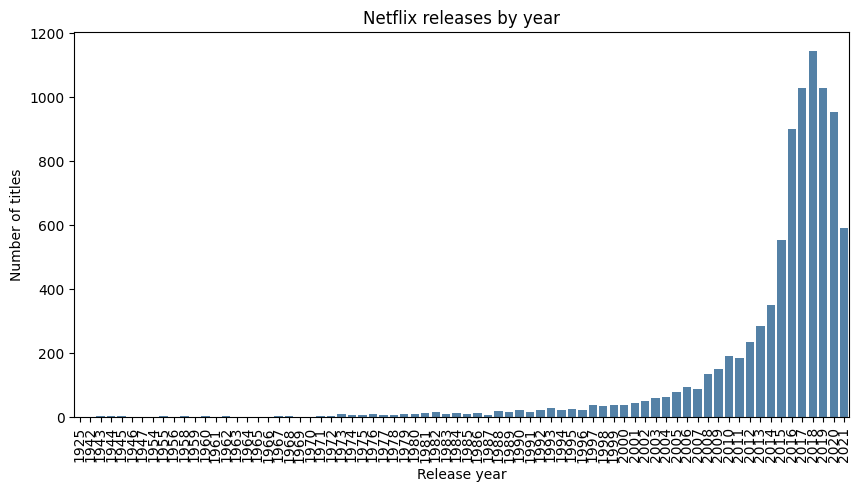

In [47]:
plt.figure(figsize=(10,5))
year_release = df['release_year'].value_counts().sort_index()
sns.barplot(x=year_release.index,
           y=year_release.values,
           color='steelblue')
plt.xticks(rotation=90)
plt.title("Netflix releases by year")
plt.xlabel('Release year')
plt.ylabel('Number of titles')
plt.show()

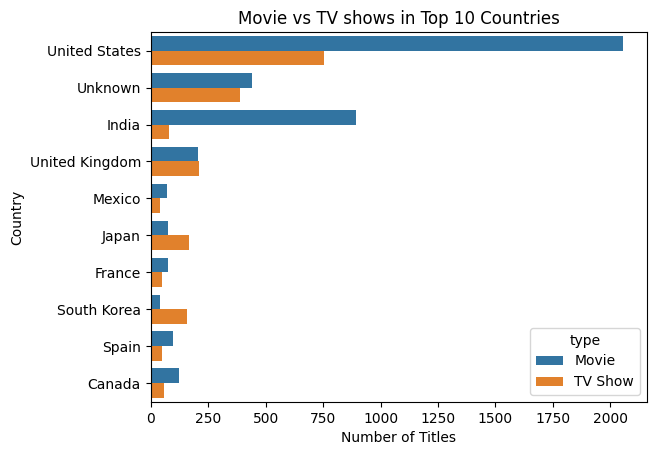

In [48]:
top10 = df['country'].value_counts().head(10).index

sns.countplot(
    data=df[df['country'].isin(top10)],
    y='country',
    hue='type'
)
plt.title('Movie vs TV shows in Top 10 Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()